In [1]:
"""

WGAN (Wasserstein GAN)
"Wasserstein GAN" (Arjovsky, Chintala & Bottou, 2017)

"""

'\n\nWGAN (Wasserstein GAN)\n"Wasserstein GAN" (Arjovsky, Chintala & Bottou, 2017)\n\n'

In [2]:
import os

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision

from tqdm import tqdm
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("spandan2/cats-faces-64x64-for-generative-models")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'cats-faces-64x64-for-generative-models' dataset.
Path to dataset files: /kaggle/input/cats-faces-64x64-for-generative-models


In [4]:
# Optimize convolution algorithms for fixed input sizes to boost training speed
torch.backends.cudnn.benchmark = True

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

total_step = 5000
batch_size = 64
latent_size = 100

lr = 0.0002

In [6]:
PRINT_INTERVAL = 25
SAMPLE_INTERVAL = 200
CHECKPOINT_INTERVAL = 1000

sample_dir = "./samples"
checkpoint_dir = "./checkpoints"
os.makedirs(sample_dir, exist_ok=True)
os.makedirs(checkpoint_dir, exist_ok=True)

image shape: torch.Size([64, 3, 32, 32])
dataset size: 15747


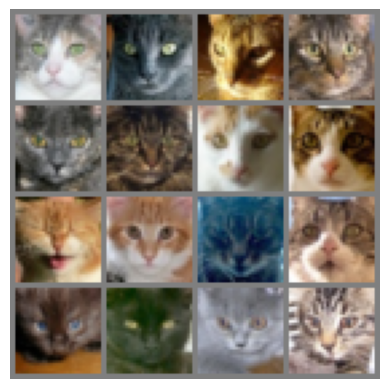

In [7]:
class ImageDataLoader:
    def __init__(self, dataloader):
        self.dataloader = dataloader
        self.iterator = iter(dataloader)

    def __iter__(self):
        return self

    def __next__(self):
        try:
            return next(self.iterator)[0]
        except StopIteration:
            self.iterator = iter(self.dataloader)
            return next(self.iterator)[0]

transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

dataset = datasets.ImageFolder(root=path, transform=transform)
data_loader = DataLoader(
    dataset=dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True
)
train_loader = ImageDataLoader(data_loader)

# Test
images = next(iter(train_loader))
print(f"image shape: {images.shape}")
print(f"dataset size: {len(dataset) // 2}")

images = torchvision.utils.make_grid(images[:16], nrow=4)
images = (images + 1) / 2 # [-1, 1] -> [0, 1]
plt.imshow(images.permute(1, 2, 0))
plt.axis("off")
plt.show()

In [8]:
#################### Generator ####################

class Generator(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(latent_size, 256 * 4 * 4),
            nn.Unflatten(1, (256, 4, 4)),

            UpBlock(256, 128), # (B, 256, 4, 4)  -> (B, 128, 8, 8)
            UpBlock(128, 64),  # (B, 128, 8, 8)  -> (B, 64, 16, 16)
            UpBlock(64, 32),   # (B, 64, 16, 16) -> (B, 32, 32, 32)

            nn.Conv2d(32, 3, 3, 1, 1), # (B, 3, 32, 32)
            nn.Tanh()
        )

        self.network.apply(init_weights)

    def forward(self, z):
        return self.network(z)

#################### UpBlock ####################

class UpBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.up = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear'),
            nn.Conv2d(in_channels, out_channels, 3, 1, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(0.2)
        )

    def forward(self, x):
        return self.up(x)

In [9]:
#################### Discriminator ####################

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            DownBlock(3, 32, use_norm=False), # 32 -> 16
            DownBlock(32, 64),                # 16 -> 8
            DownBlock(64, 128),               # 8 -> 4

            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 1),
        )

        self.network.apply(init_weights)

    def forward(self, image):
        return self.network(image)

#################### DownBlock ####################

class DownBlock(nn.Module):
    def __init__(self, in_channels, out_channels, use_norm=True):
        super().__init__()

        self.down = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, 2, 1, bias=not use_norm),
            nn.BatchNorm2d(out_channels) if use_norm else nn.Identity(),
            nn.LeakyReLU(0.2)
        )

    def forward(self, x):
        return self.down(x)

In [10]:
def init_weights(m):
    if isinstance(m, torch.nn.Conv2d) or isinstance(m, torch.nn.ConvTranspose2d):
        torch.nn.init.normal_(m.weight, 0.0, 0.02)
    elif isinstance(m, torch.nn.BatchNorm2d):
        torch.nn.init.normal_(m.weight, 1.0, 0.02)
        torch.nn.init.zeros_(m.bias)

In [11]:
def visualize_sample(fixed_z, step):
    generator.eval()
    with torch.no_grad():
        fake_images = generator(fixed_z).cpu()
        fake_images = (fake_images + 1) / 2  # [-1, 1] -> [0, 1]

        grid = torchvision.utils.make_grid(fake_images, nrow=8)
        plt.figure(figsize=(16, 4))
        plt.imshow(grid.permute(1, 2, 0))
        plt.axis("off")
        plt.tight_layout()
        plt.show()

        torchvision.utils.save_image(
            fake_images,
            f"{sample_dir}/step_{step:03d}.png",
            nrow=8
        )
    generator.train()

def save_checkpoint(step):
    torch.save({
        "step": step,
        "generator": generator.state_dict(),
        "discriminator": discriminator.state_dict(),
        "optimizer_G": optimizer_G.state_dict(),
        "optimizer_D": optimizer_D.state_dict(),
    }, f"{checkpoint_dir}/gan_step_{step:03d}.pth")

def load_checkpoint(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)

    generator.load_state_dict(checkpoint["generator"])
    discriminator.load_state_dict(checkpoint["discriminator"])
    optimizer_G.load_state_dict(checkpoint["optimizer_G"])
    optimizer_D.load_state_dict(checkpoint["optimizer_D"])
    start_step = checkpoint["step"]
    print(f"Loaded checkpoint: {checkpoint_path} (step {start_step})")
    return start_step

In [12]:
generator = Generator().to(device)
discriminator = Discriminator().to(device)

optimizer_G = optim.RMSprop(generator.parameters(), lr=lr)
optimizer_D = optim.RMSprop(discriminator.parameters(), lr=lr)

In [13]:
# if pretrained
# path = "./checkpoints/gan_epoch_1000.pth"
# start_step = load_checkpoint(path)
start_step = 0

D_loss: -0.0069  G_loss: -0.0076  D(x): 0.014  D(G(z)): 0.008:   4%|▍         | 199/5000 [01:02<24:25,  3.28it/s]

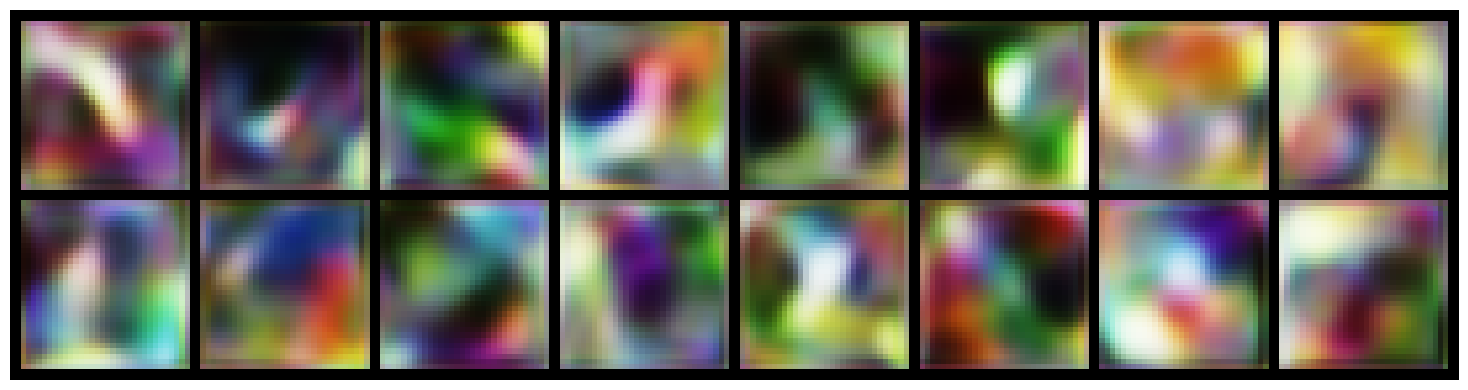

D_loss: -0.0386  G_loss: 0.0158  D(x): 0.021  D(G(z)): -0.018:   8%|▊         | 399/5000 [01:59<21:33,  3.56it/s]

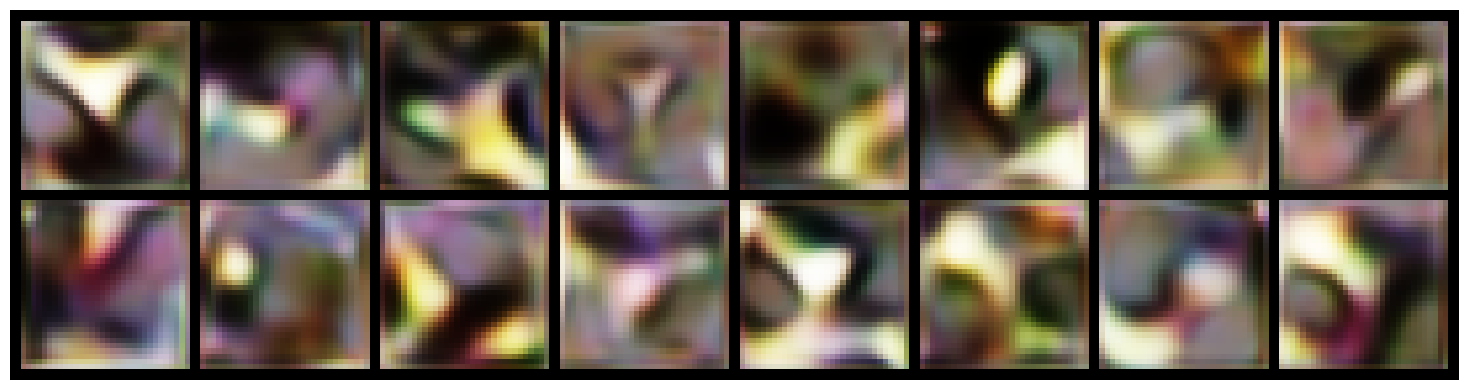

D_loss: -0.0641  G_loss: 0.0320  D(x): 0.029  D(G(z)): -0.035:  12%|█▏        | 599/5000 [02:35<06:28, 11.34it/s]

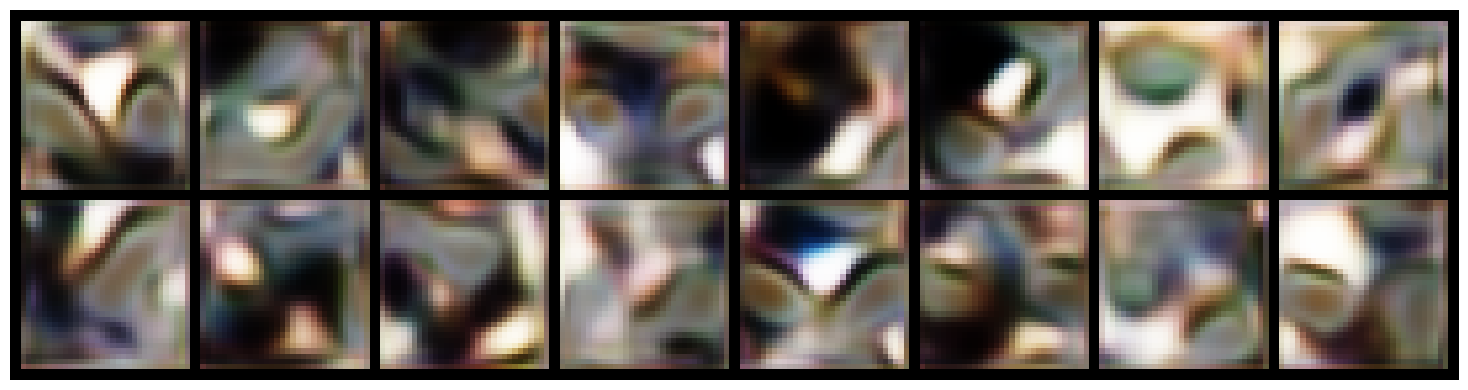

D_loss: -0.0617  G_loss: 0.0371  D(x): 0.025  D(G(z)): -0.036:  16%|█▌        | 799/5000 [02:54<06:23, 10.96it/s]

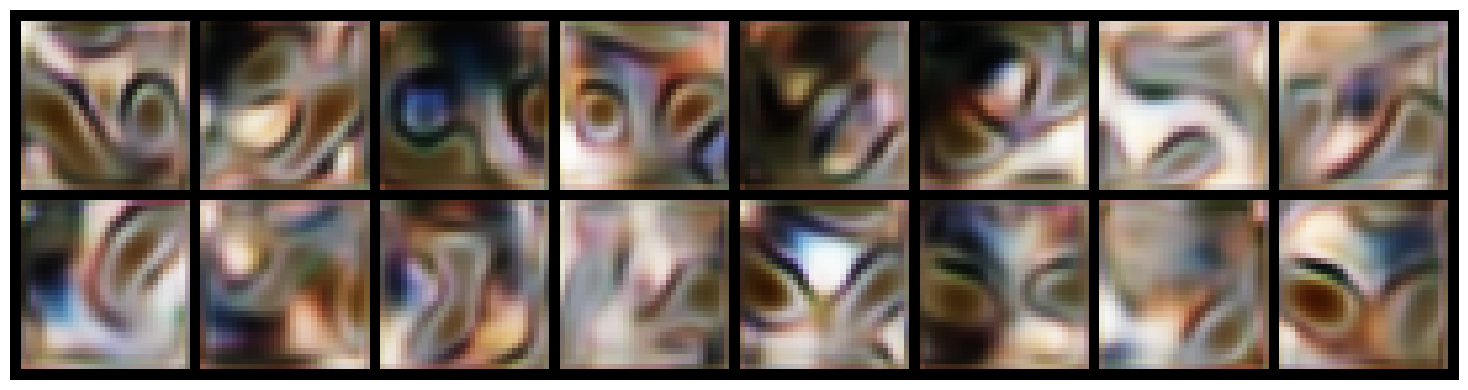

D_loss: -0.0580  G_loss: 0.0273  D(x): 0.027  D(G(z)): -0.031:  20%|█▉        | 998/5000 [03:12<06:05, 10.96it/s]

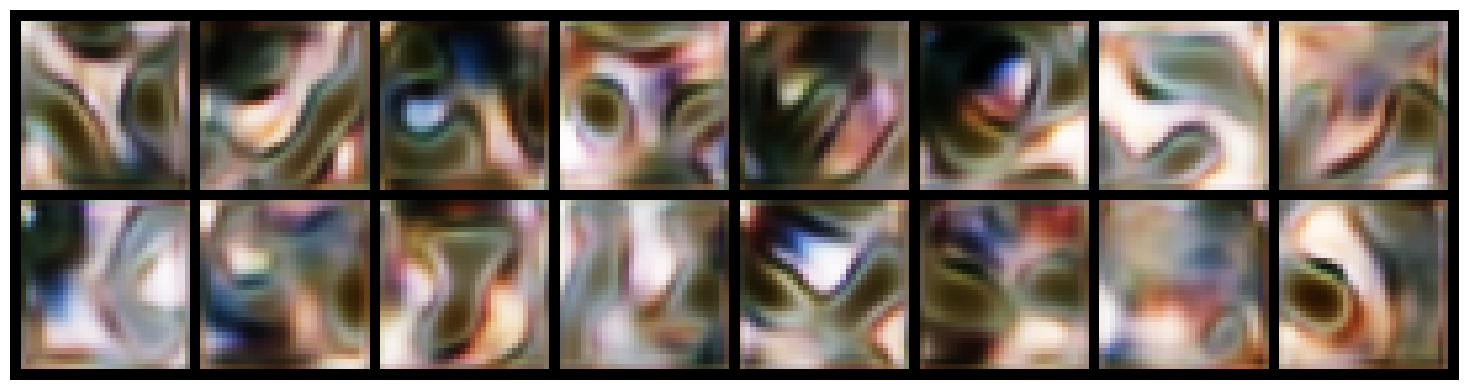

D_loss: -0.0549  G_loss: 0.0303  D(x): 0.029  D(G(z)): -0.026:  24%|██▍       | 1199/5000 [03:30<05:43, 11.08it/s]

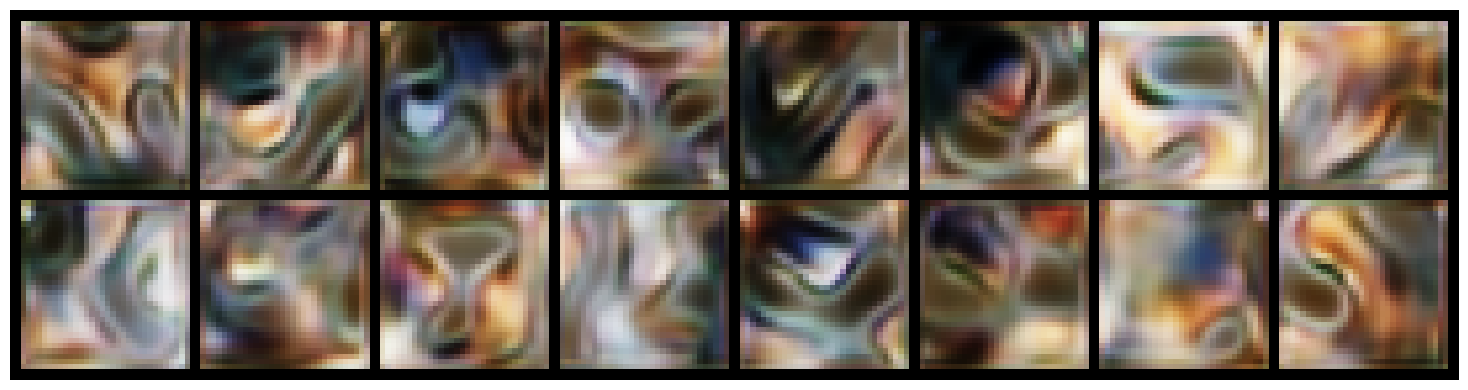

D_loss: -0.0514  G_loss: 0.0282  D(x): 0.032  D(G(z)): -0.020:  28%|██▊       | 1399/5000 [03:49<05:25, 11.06it/s]

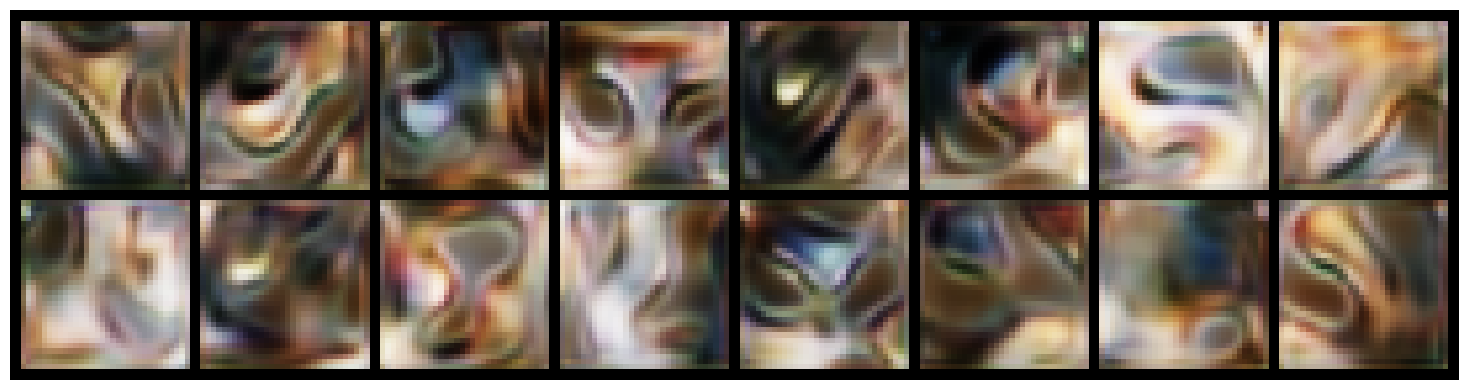

D_loss: -0.0412  G_loss: 0.0266  D(x): 0.016  D(G(z)): -0.025:  32%|███▏      | 1599/5000 [04:08<05:01, 11.29it/s]

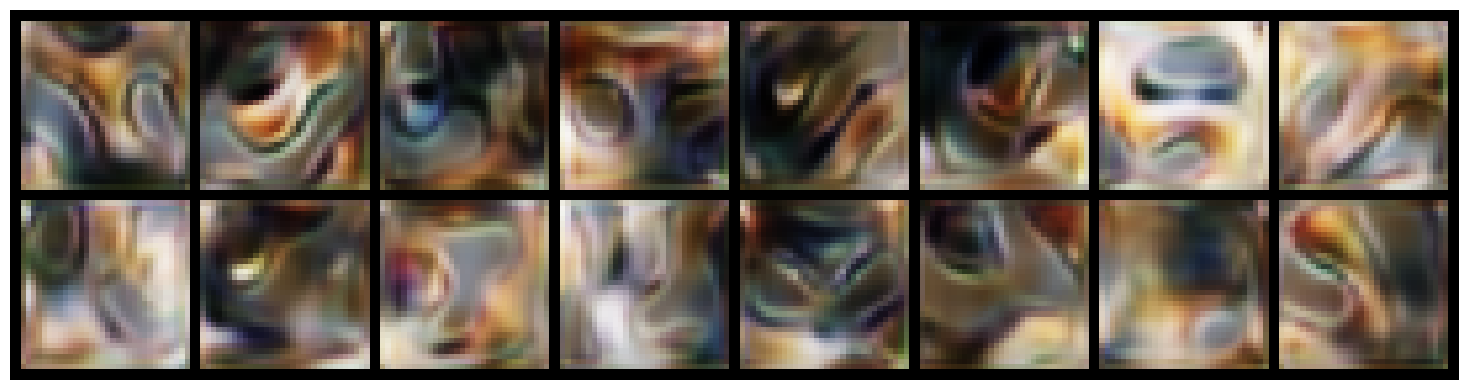

D_loss: -0.0480  G_loss: 0.0206  D(x): 0.020  D(G(z)): -0.028:  36%|███▌      | 1798/5000 [04:26<04:34, 11.68it/s]

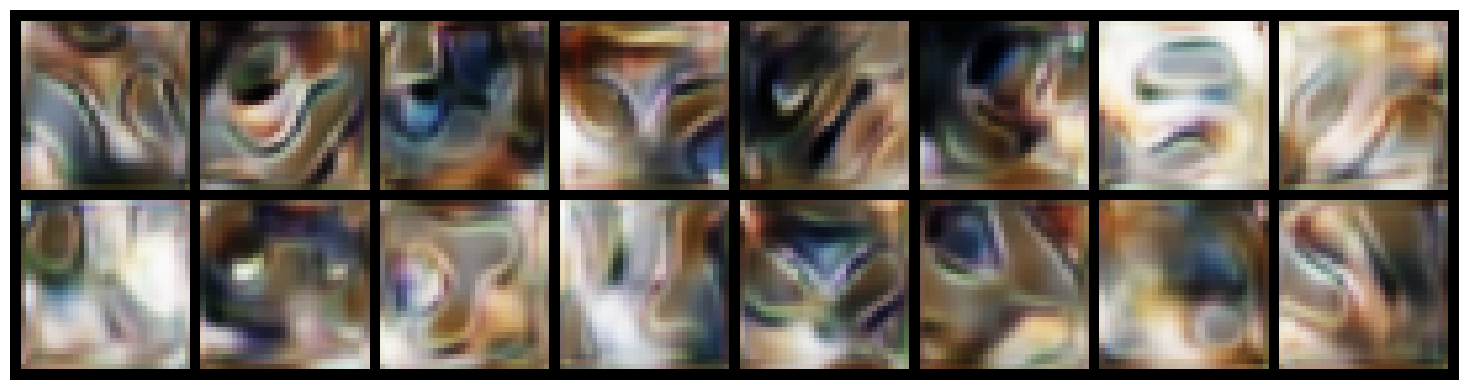

D_loss: -0.0496  G_loss: 0.0250  D(x): 0.034  D(G(z)): -0.016:  40%|███▉      | 1998/5000 [04:44<04:30, 11.10it/s]

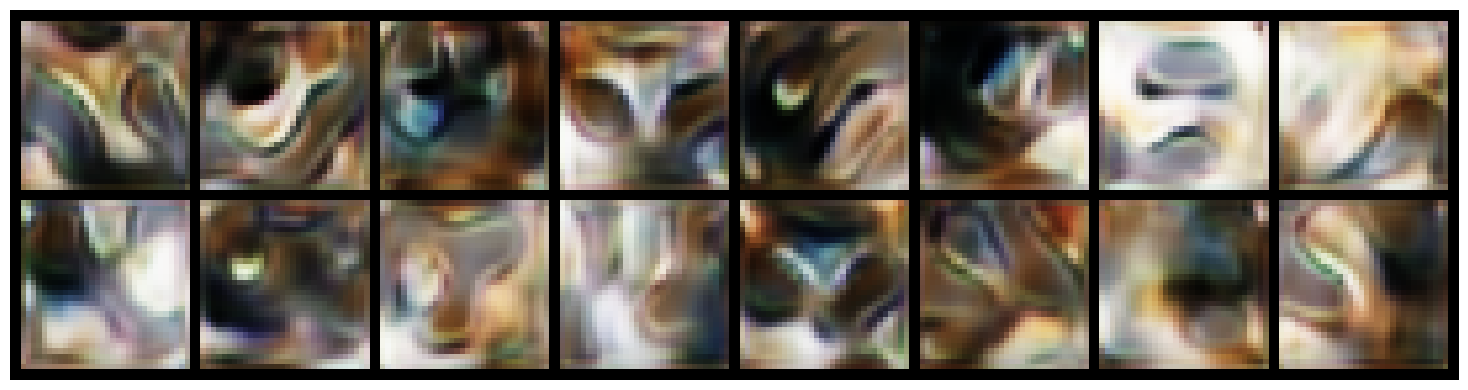

D_loss: -0.0379  G_loss: 0.0210  D(x): 0.020  D(G(z)): -0.018:  44%|████▍     | 2199/5000 [05:02<04:13, 11.03it/s]

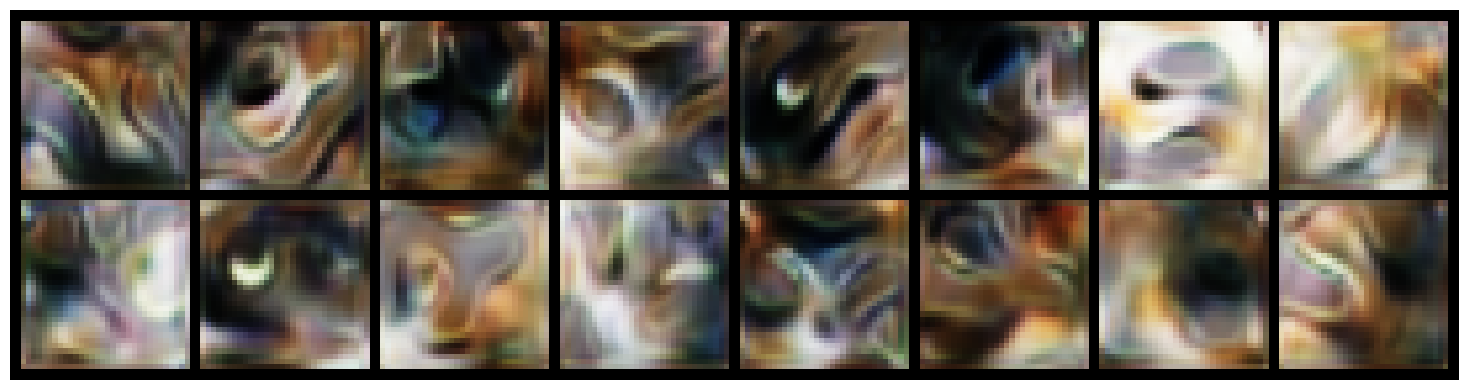

D_loss: -0.0331  G_loss: 0.0162  D(x): 0.015  D(G(z)): -0.018:  48%|████▊     | 2398/5000 [05:21<03:51, 11.24it/s]

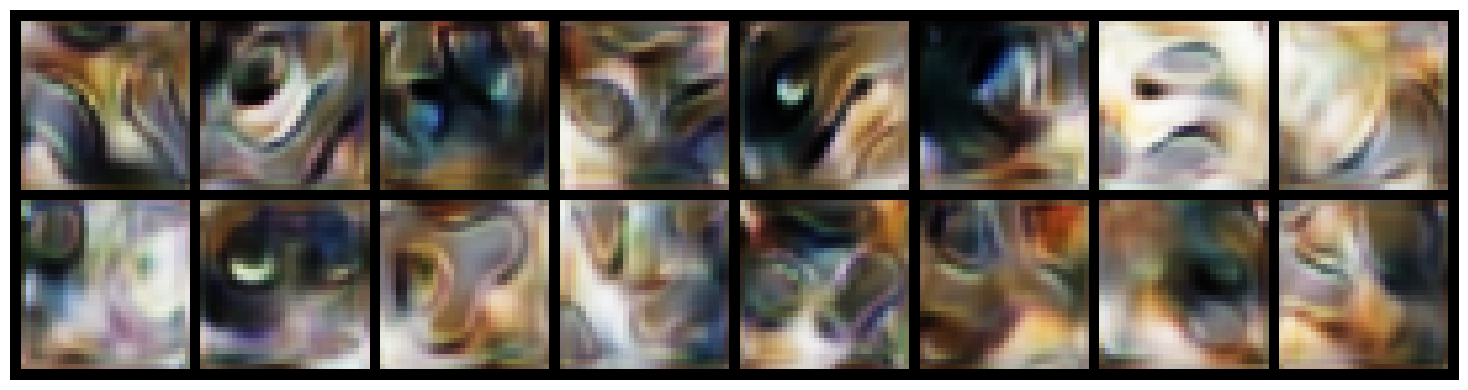

D_loss: -0.0313  G_loss: 0.0175  D(x): 0.012  D(G(z)): -0.019:  52%|█████▏    | 2599/5000 [05:39<03:26, 11.62it/s]

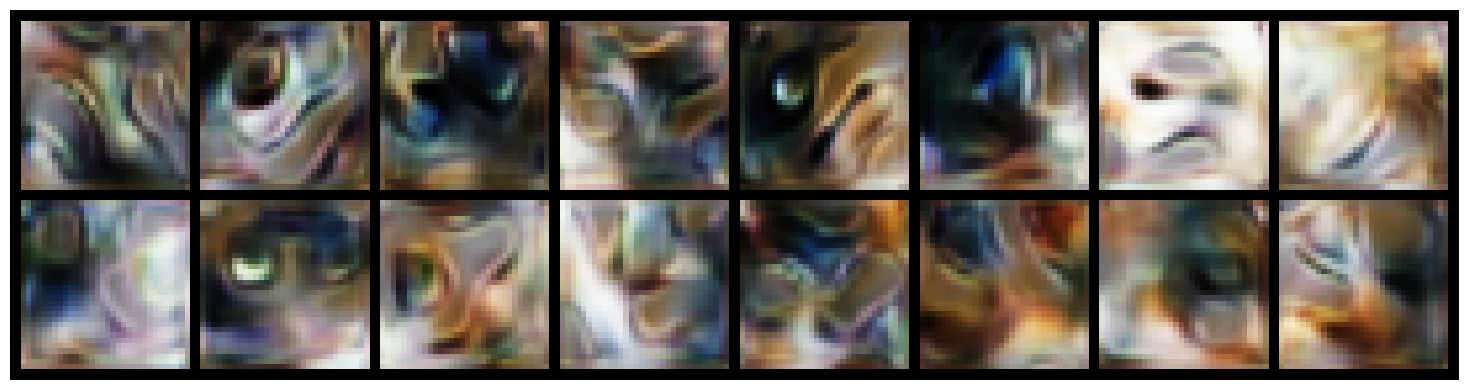

D_loss: -0.0289  G_loss: 0.0134  D(x): 0.011  D(G(z)): -0.018:  56%|█████▌    | 2799/5000 [05:58<03:24, 10.78it/s]

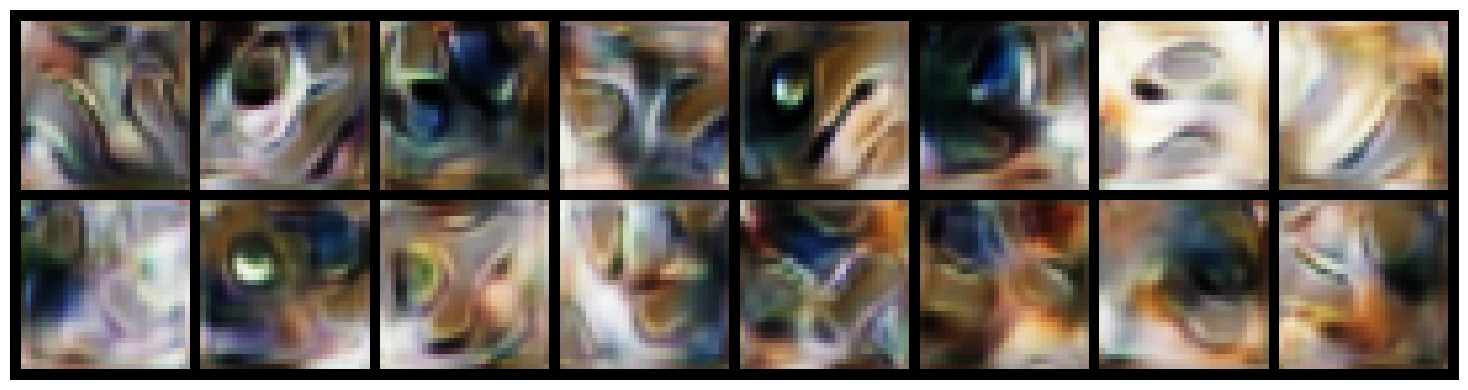

D_loss: -0.0264  G_loss: 0.0108  D(x): 0.011  D(G(z)): -0.015:  60%|█████▉    | 2998/5000 [06:16<02:54, 11.45it/s]

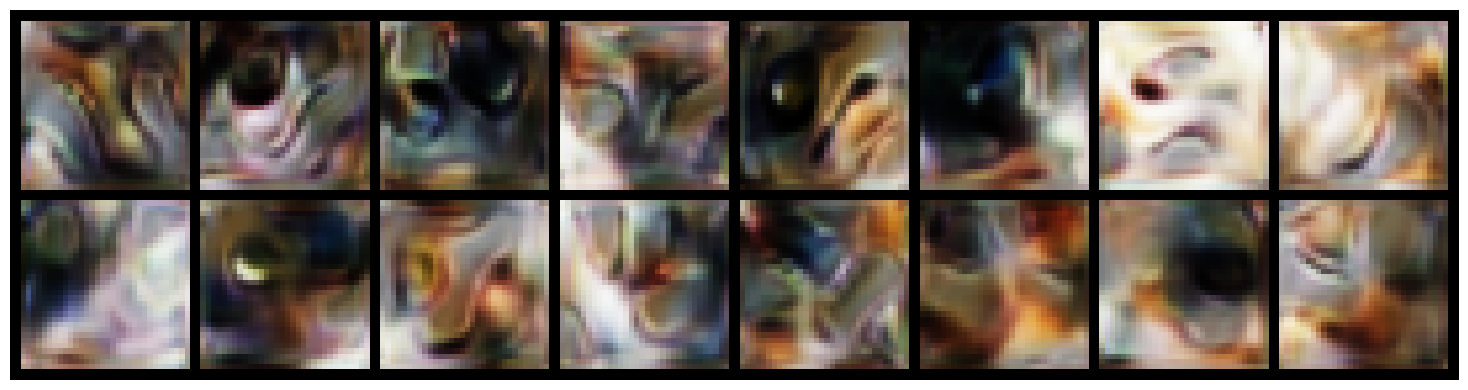

D_loss: -0.0269  G_loss: 0.0159  D(x): 0.011  D(G(z)): -0.016:  64%|██████▍   | 3198/5000 [06:35<02:40, 11.26it/s]

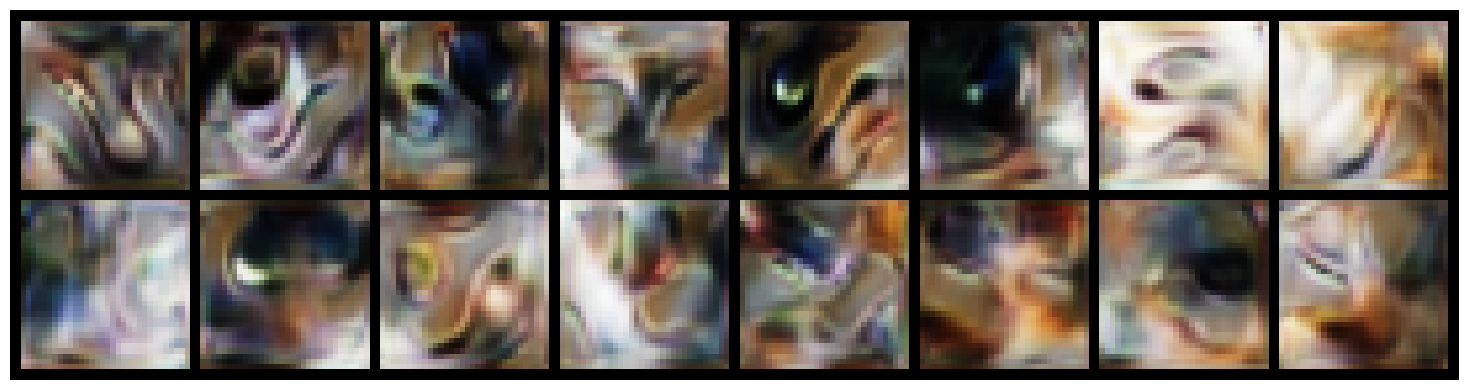

D_loss: -0.0303  G_loss: 0.0142  D(x): 0.006  D(G(z)): -0.025:  68%|██████▊   | 3398/5000 [06:53<02:21, 11.34it/s]

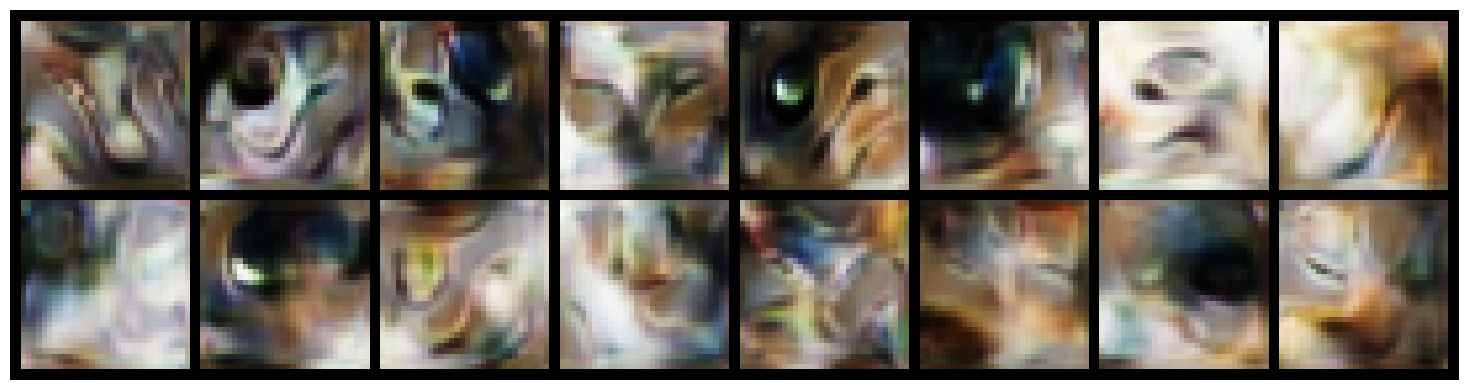

D_loss: -0.0307  G_loss: 0.0137  D(x): 0.014  D(G(z)): -0.016:  72%|███████▏  | 3598/5000 [07:12<02:07, 10.96it/s]

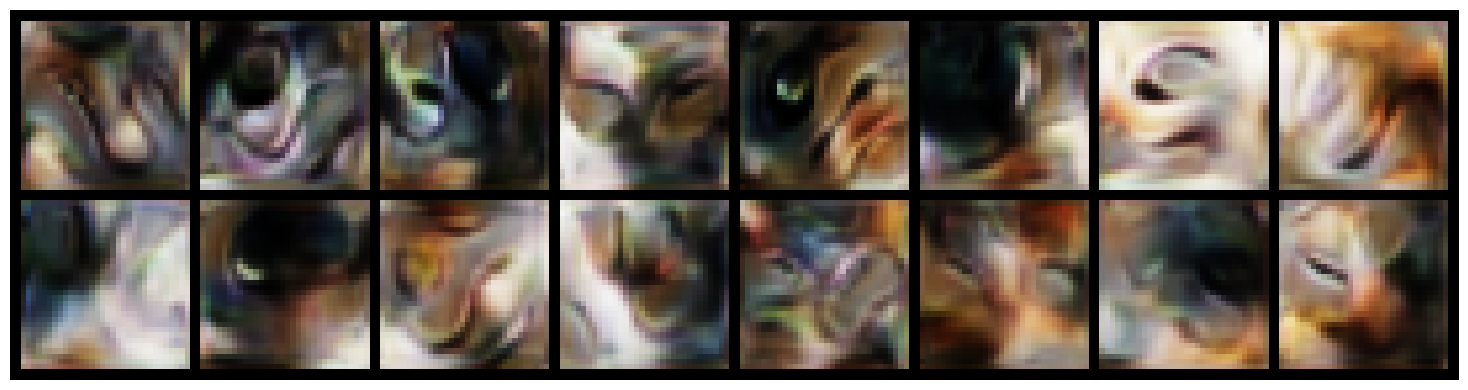

D_loss: -0.0247  G_loss: 0.0084  D(x): 0.020  D(G(z)): -0.005:  76%|███████▌  | 3798/5000 [07:30<01:45, 11.38it/s]

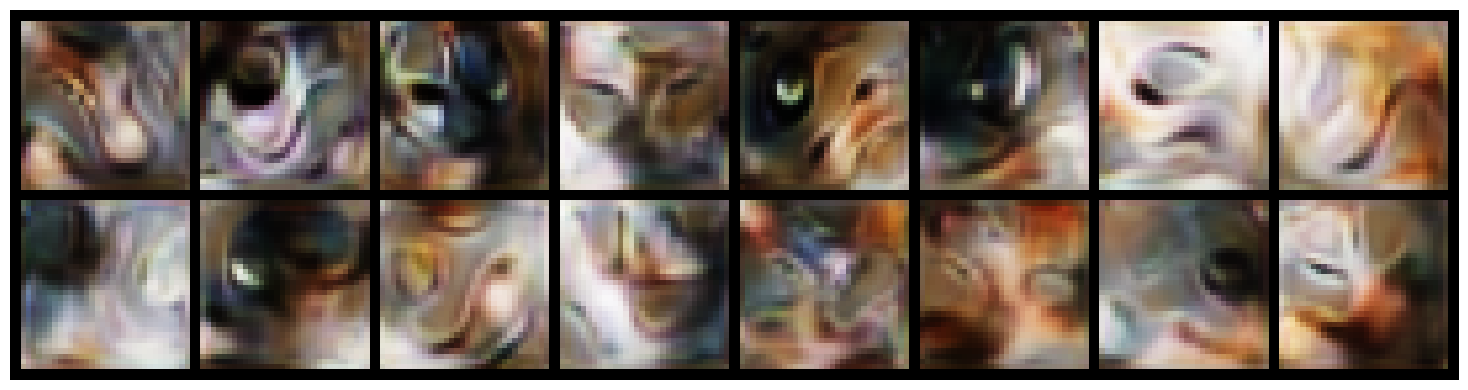

D_loss: -0.0233  G_loss: 0.0189  D(x): 0.011  D(G(z)): -0.012:  80%|███████▉  | 3999/5000 [07:49<01:31, 10.93it/s]

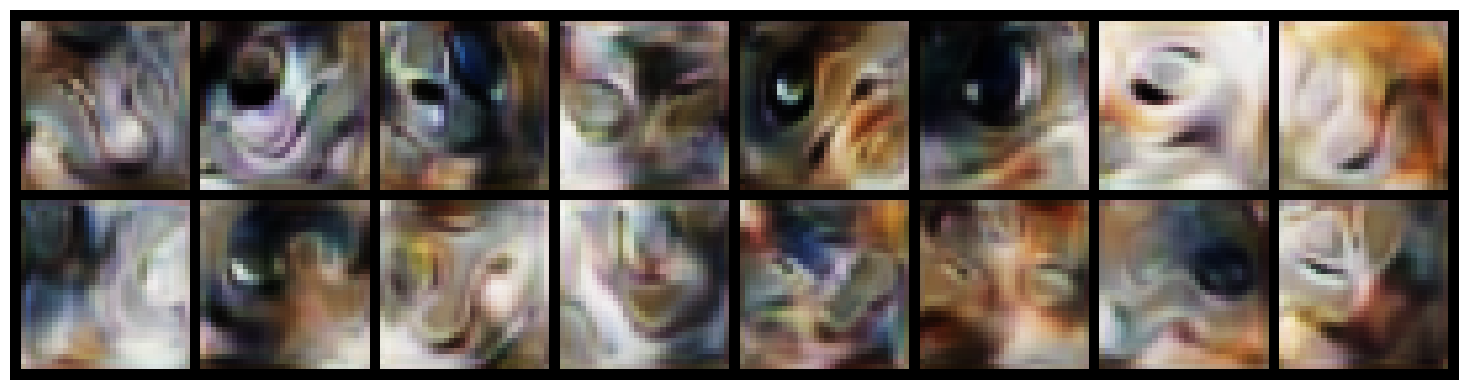

D_loss: -0.0279  G_loss: 0.0107  D(x): 0.020  D(G(z)): -0.008:  84%|████████▍ | 4198/5000 [08:08<01:13, 10.95it/s]

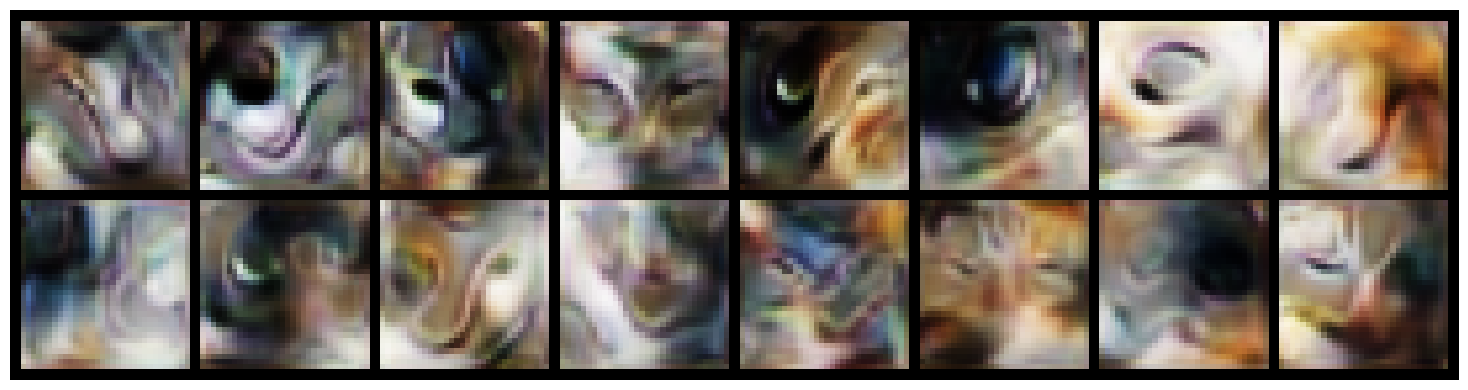

D_loss: -0.0254  G_loss: 0.0080  D(x): 0.009  D(G(z)): -0.016:  88%|████████▊ | 4399/5000 [08:27<00:56, 10.68it/s]

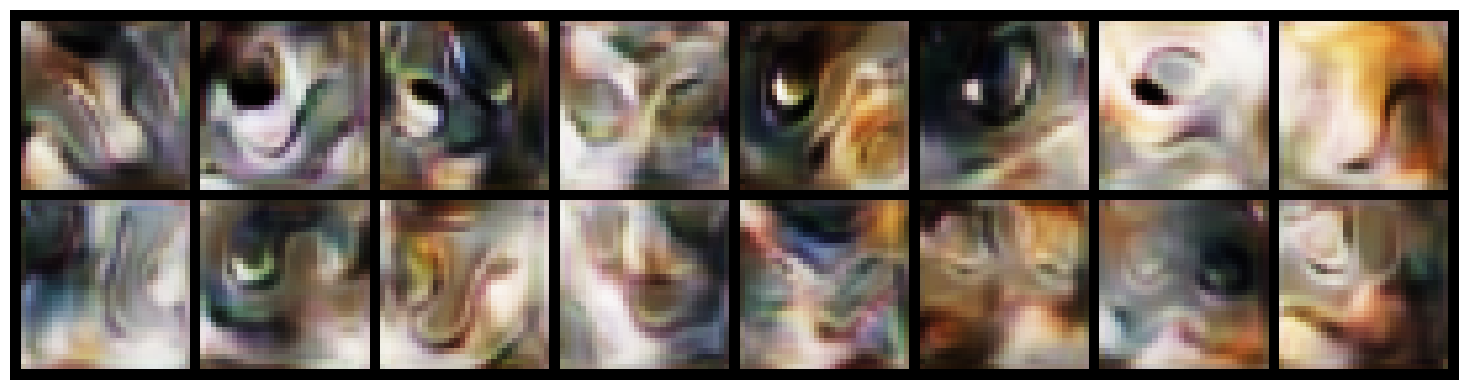

D_loss: -0.0245  G_loss: 0.0115  D(x): 0.011  D(G(z)): -0.014:  92%|█████████▏| 4598/5000 [08:45<00:35, 11.20it/s]

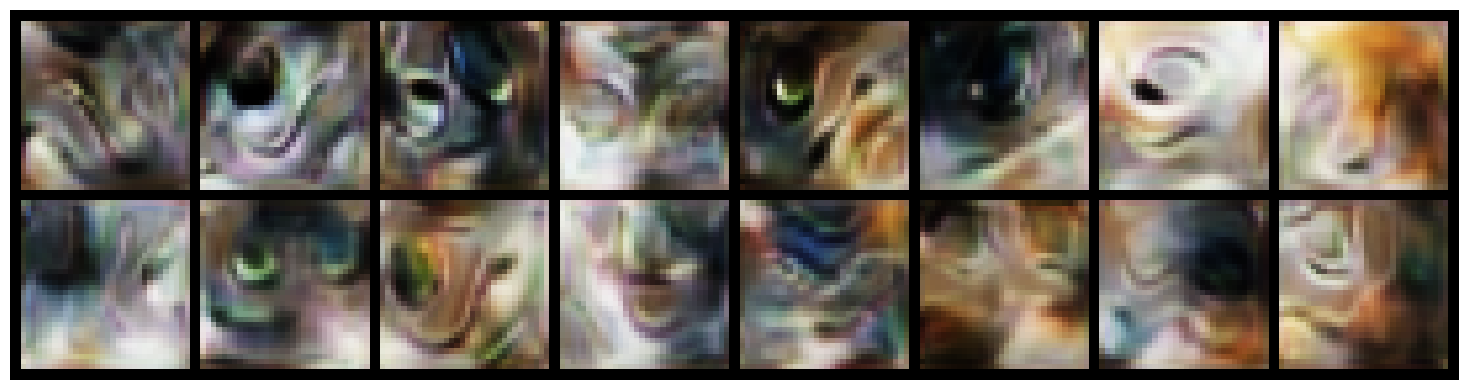

D_loss: -0.0211  G_loss: 0.0144  D(x): 0.007  D(G(z)): -0.014:  96%|█████████▌| 4799/5000 [09:04<00:18, 10.86it/s]

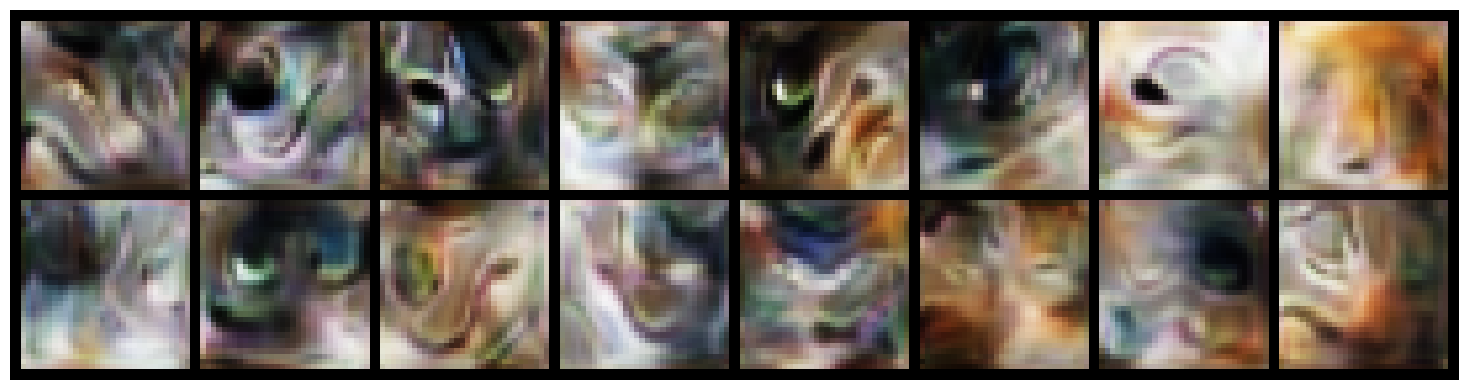

D_loss: -0.0187  G_loss: 0.0175  D(x): 0.004  D(G(z)): -0.014: 100%|█████████▉| 4998/5000 [09:23<00:00, 11.17it/s]

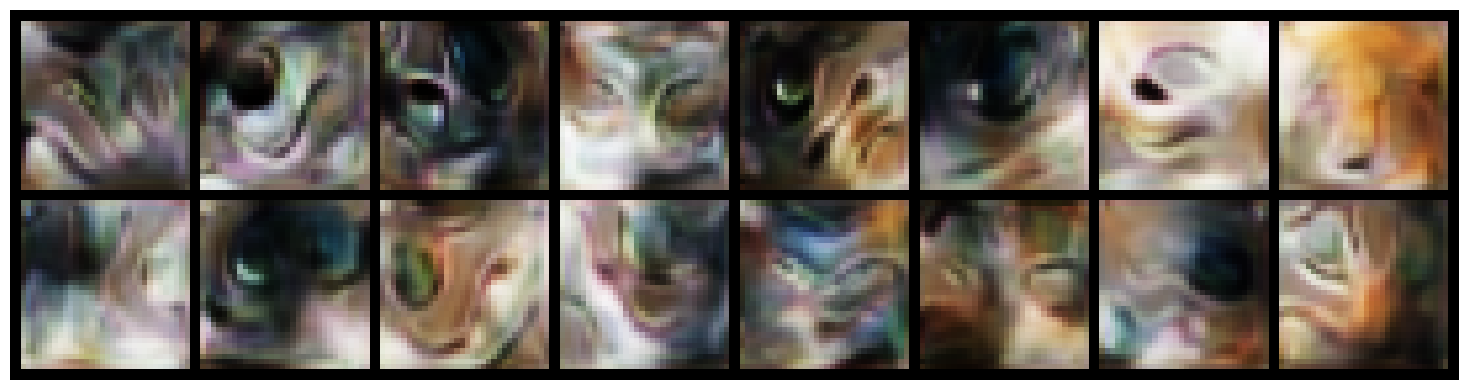

D_loss: -0.0187  G_loss: 0.0175  D(x): 0.004  D(G(z)): -0.014: 100%|██████████| 5000/5000 [09:23<00:00,  8.87it/s]


In [14]:
########## Train ##########

fixed_z_generator = torch.Generator(device=device).manual_seed(42)
fixed_z = torch.randn(16, latent_size, generator=fixed_z_generator, device=device) # for eval
# real_targets = torch.ones(batch_size, 1, device=device)  # (b, 1)
# fake_targets = torch.zeros(batch_size, 1, device=device) # (b, 1)

pbar = tqdm(range(start_step, total_step), desc="WGAN")
loss_G = torch.tensor(0.0)

for step in pbar:
    real_images = next(train_loader).to(device)

    ########## D Train ##########
    z = torch.randn(batch_size, latent_size, device=device)
    with torch.no_grad():
        fake_images = generator(z)

    d_real = discriminator(real_images)
    d_fake = discriminator(fake_images)
    loss_D = -torch.mean(d_real) + torch.mean(d_fake)

    optimizer_D.zero_grad()
    loss_D.backward()
    optimizer_D.step()

    for p in discriminator.parameters():
        p.data.clamp_(-0.01, 0.01)

    ########## G Train ##########
    if step % 5 == 0:
        z = torch.randn(batch_size, latent_size, device=device)
        fake_images = generator(z)
        d_fake = discriminator(fake_images)
        loss_G = -torch.mean(d_fake)

        optimizer_G.zero_grad()
        loss_G.backward()
        optimizer_G.step()

    ########## Log ##########

    if (step + 1) % PRINT_INTERVAL == 0:
        pbar.set_description(
            f"D_loss: {loss_D.item():.4f}  G_loss: {loss_G.item():.4f}  "
            f"D(x): {d_real.mean().item():.3f}  D(G(z)): {d_fake.mean().item():.3f}"
        )

    if (step + 1) % SAMPLE_INTERVAL == 0:
        visualize_sample(fixed_z, step + 1)

    if (step + 1) % CHECKPOINT_INTERVAL == 0:
        save_checkpoint(step + 1)